 Ce document est le TP n°1 du module IA de l'université de Toulouse.  Il reprend rapidement des éléments du cours et propose une mise en pratique interactive des notions de densité, de variance et de normalité.

Vous êtes un jeune entrepreneur désireux de faire fortune dans les jeux vidéo. Comme vous avez beaucoup d'imagination mais peu d'argent, vous souhaitez investir là où vous êtes sûr de faire du profit. Vous allez observer des données issues de ventes de jeux vidéo afin de faire votre propre étude de marché.

Cet ensemble de données contient une liste de jeux vidéo du genre "Action'. Il a été généré par le site de vgchartz.com.


Les champs incluent
*   name : Nom du jeu
*   console : Plate-forme de la version des jeux (c'est-à-dire PC, PS4, etc.)
*   genre : Genre du jeu
*   publisher : Éditeur du jeu
*   na_sales : Ventes en Amérique du Nord (en millions)
*   pal_sales : Ventes en dans les pays du réseau Pal (en millions)
*   jp_sales : Ventes au Japon (en millions)
*   other_sales : Ventes dans le reste du monde (en millions)
*   total_sales : Total des ventes mondiales.



Après avoir téléchargé le fichier vgchartz-2_1_2024.csv chargez-le dans le fichier jupyter

In [2]:
# from google.colab import files
# uploaded = files.upload()

La fonction read\_csv() de la librairie Pandas lit des données de type csv pour les stocker dans un dataframe.

À moins de vouloir faire frémir un statisticien, vous ne touchez pas aux données originales (car vous risquez de faire n'importe quoi au cours de ce T. P. sur ces pauvres données qui n'ont rien demandé).
Il faut donc copier les données dans un deuxième

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Data = pd.read_csv('vgchartz-2_1_2024.csv')


Stocker les données dans une variable df avec la fonction pd.read_csv() (elles sont présentent sous le nom vgchartz-2_1_2024.csv). On note cette variable df pour dataframe.


In [4]:
df = pd.read_csv('vgchartz-2_1_2024.csv')

Il est temps de distinguer une tendance sur les données! Pour cela, la fonction describe() vous donne des informations sur la répartition sur toute vos variables numériques.

Appliquer la fonction describe() à votre dataframe

In [5]:
df.describe()

,vg_score,critic_score,user_score,total_shipped,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,1043.000000,4334.000000,257.000000,4303.000000,11797.000000,9941.000000,4008.000000,9271.000000,10622.000000
mean,7.627709,7.387425,8.474708,5.028706,0.550432,0.333056,0.155322,0.205720,0.061593
std,1.338636,1.367820,1.237067,21.645171,0.982478,0.546074,0.201680,0.454762,0.149068
min,2.000000,1.500000,2.000000,0.070000,0.070000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,6.600000,8.000000,0.260000,0.130000,0.090000,0.040000,0.030000,0.010000
50%,8.000000,7.600000,8.800000,1.000000,0.260000,0.160000,0.090000,0.080000,0.020000
75%,8.600000,8.400000,9.300000,3.000000,0.560000,0.350000,0.190000,0.200000,0.050000
max,9.700000,10.000000,10.000000,520.000000,20.320000,9.760000,2.130000,9.850000,3.120000


Cherchez et citez à quoi correspond un objet de type dataframe sous Python.


<p>Un objet de type dataframe est <i> "a 2 dimensional data structure, like a 2 dimensional array, or a table with rows and columns."</i> <br>
<i> source: <a href="https://www.w3schools.com/python/pandas/pandas_dataframes.asp"> w3schools.com : Pandas Dataframe </p>

Vérifiez la moyenne de la colonne jp_sales avec la fonction mean(). Comparez avec celle donnée par la fonction describe().


In [6]:
# On sélectionne seulement la colonne jp_sales
jp_sales = df['jp_sales']
print(f"Mean : {jp_sales.mean()}")

print(jp_sales.describe())

Mean : 0.15532185628742515
count    4008.000000
mean        0.155322
std         0.201680
min         0.000000
25%         0.040000
50%         0.090000
75%         0.190000
max         2.130000
Name: jp_sales, dtype: float64


<p>On remarque juste que le mean de describe est arrondi tandis que le mean direct non</p>

Quel a été le plus vendu?


In [7]:
# On cherche la ligne avec la plus grande valeur de ventes total
le_plus_vendu = df.loc[df['total_sales'].idxmax()] # On retroune l'index avec la valeur la plus grande dans 'total_sales'
print(le_plus_vendu)


img              /games/boxart/full_6510540AmericaFrontccc.jpg
title                                       Grand Theft Auto V
console                                                    PS3
genre                                                   Action
publisher                                       Rockstar Games
developer                                       Rockstar North
vg_score                                                   9.5
critic_score                                               9.4
user_score                                                 NaN
total_shipped                                              NaN
total_sales                                              20.32
na_sales                                                  6.37
jp_sales                                                  0.99
pal_sales                                                 9.85
other_sales                                               3.12
release_date                                        201

Quel zone géographique a eu les meilleures ventes?


In [8]:
# On retourne le max entre na_sales, jp_sales, pal_sales et other_sales
region = le_plus_vendu.loc[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].idxmax()
print(f"La région avec les ventes les plus élevées est {region}")

La région avec les ventes les plus élevées est pal_sales


## Notion de densité

Vous allez observer la densité de probabilité des données. En physique, la densité ou densité d'un corps est le rapport de sa masse volumique à la masse volumique d'un corps pris comme référence, c'est à dire que nous comparons le nombre d'une variable par rapport à un ensemble de variables observées. En théorie des probabilités ou en statistique, une densité de probabilité est une fonction qui permet de représenter une loi de probabilité sous forme d'intégrales.
 Dans un histogramme, la densité en un point $x$ est estimée par la proportion d'observations $x_1, x_2, ..., x_N$ qui se trouvent à proximité de $x$. Pour cela, nous traçons une boîte en $x$ et dont la largeur est définie par un paramètre de lissage $h$ (soit la largeur de la  boîte); nous comptons ensuite le nombre d'observations qui appartiennent à cette boîte.
Le problème avec les histogrammes, c'est que :
*  nous devons définir le paramètre $h$ (dans R il est calculé automatiquement)
*  les histogrammes produisent une estimation de la fréquence non continue.


La fonction plot(kind = 'density') fournit une estimation par noyau (ou encore méthode de Parzen-Rosenblatt, 1962). C'est une méthode non paramétrique d’estimation de la densité de probabilité d’une variable aléatoire. Elle se base sur un échantillon d’une population et permet d’estimer la densité de probabilité en tout point du support (intervalle min et max des valeurs observées).

Cette méthode du noyau consiste à retrouver la continuité : pour cela, nous remplaçons la boîte centrée en $x$ et de largeur $h$ par une loi gaussienne (définie par la suite) centrée en $x$. Plus une observation est proche du point de support $x$ plus la courbe en cloche lui donnera une valeur numérique importante. À l'inverse, les observations trop éloignées de $x$ se voient affecter d'une valeur numérique négligeable. Notez également que plus il y a d'observations dans le voisinage d'un point, plus sa densité est élevée. La méthode du noyau  est plus précise qu'un simple histogramme (fonction hist())

Affichons les total_sales à l'aide des fonctions hist() et plot()

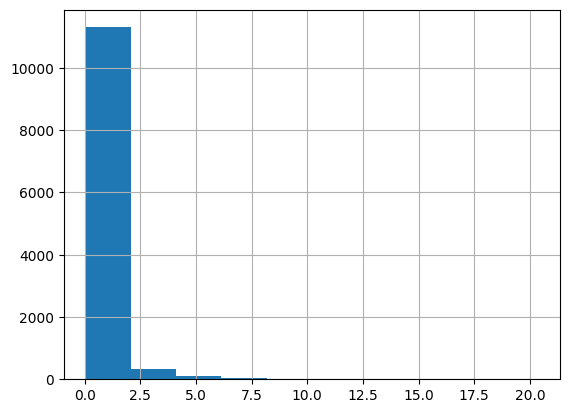

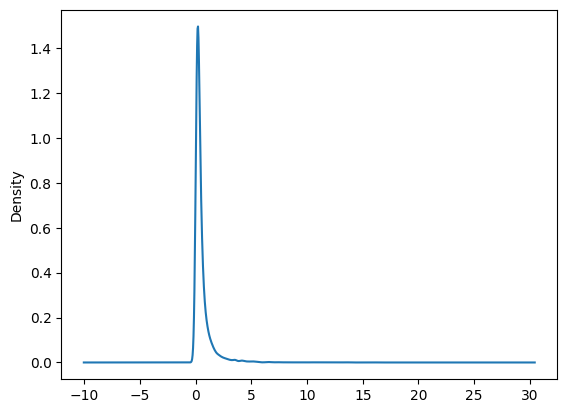

In [9]:
df["total_sales"].hist()
plt.show()


df["total_sales"].plot(kind = 'density')
plt.show()

Affichons l'histogramme par année

In [10]:
def extract_year(df, date_column):
    df['Year'] = pd.to_datetime(df[date_column]).dt.year
    return df

In [11]:
pd.to_datetime(df.iloc[[176]]['release_date']).dt.year

176    2013
Name: release_date, dtype: int32

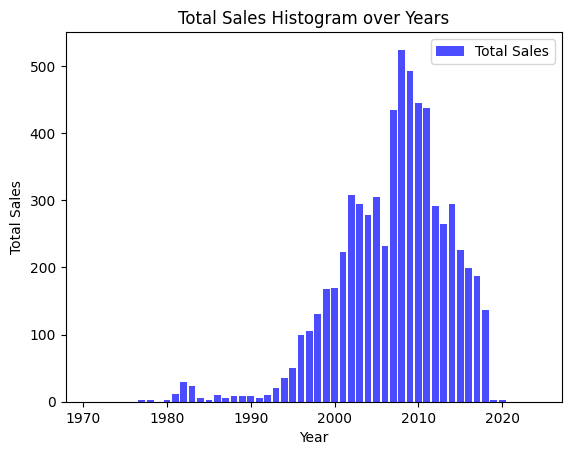

In [12]:
import matplotlib.pyplot as plt

df_temp =  extract_year(df, 'release_date')
# Groupage par année et somme  des ventes totales
sales_per_year = df.groupby(df_temp['Year'])['total_sales'].sum()

plt.bar(sales_per_year.index, sales_per_year.values, color='blue', alpha=0.7, label='Total Sales')


plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Total Sales Histogram over Years')
plt.legend()

 Y-a-il une année qui se démarque des autres? Laquelle?


In [13]:
# On veut retourner l'année avec laquel il y a eu le plus de ventes totales
print(f"L'année avec les ventes les plus élevées est {sales_per_year.idxmax()} avec {sales_per_year.max()} ventes totales.")

L'année avec les ventes les plus élevées est 2008.0 avec 523.96 ventes totales.


<p>On remarque qu'il y a un pic entre 2007 et 2012 avec le plus de vente en 2008</p>

Pourquoi certaines valeurs extrêmes peuvent-elles fausser l'interprétation d'une variable ?

<p>Si une valeur est bien trop différente par rapport aux autres, alors elle peut avoir un mauvais impact sur la moyenne, surtout si cette valeur est toute seule. 
Un exemple dans notre database serait d'avoir un énorme pic en 80. 
Dans ce cas la moyenne ne serait plus autour de 2008, où la plupart des valeurs se trouvent, mais plutôt vers 1990/2000.</p>

Utilisez l'option kind='box' de la fonction plot sur votre dataframe df. À quoi ce graphique correspond-t-il ?

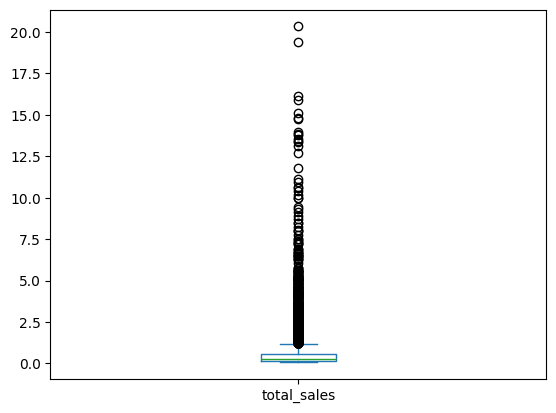

In [14]:
df["total_sales"].plot(kind='box' )
plt.show()

Un bloxplot (ou boite à moustache) permet de représenter l'EIQ (l'étendu interquertile) qui est représenté par: 
$ 
    EIQ = Q_3 - Q_1 
$ 
avec $ Q1 $ la médiane des petites valeurs et $ Q3 $ la médiane des Grandes valeurs. <br>
Si notre valeur est a 1.5 $ EIQ $ des limites de la boite, alors c'est une <b>valeur extrême</b> qu'on représente par des points ici en noir. 

Notre dataset n'est supposé avoir que des jeux du genre 'Action'. Vérifions cela...

<Axes: xlabel='genre', ylabel='pal_sales'>

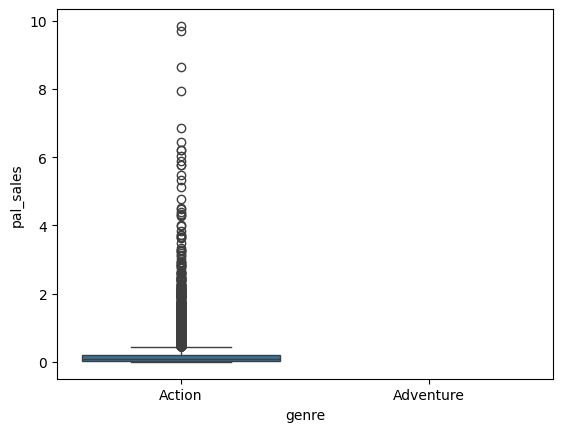

In [15]:
import seaborn as sns

# sns.set(rc={'figure.figsize':(11.7,8.27)})

#create boxplot by group
sns.boxplot(x='genre', y='pal_sales', data=df)

Supprimez du dataset df les jeux d'un autre genre que celui d'action

<Axes: xlabel='genre', ylabel='pal_sales'>

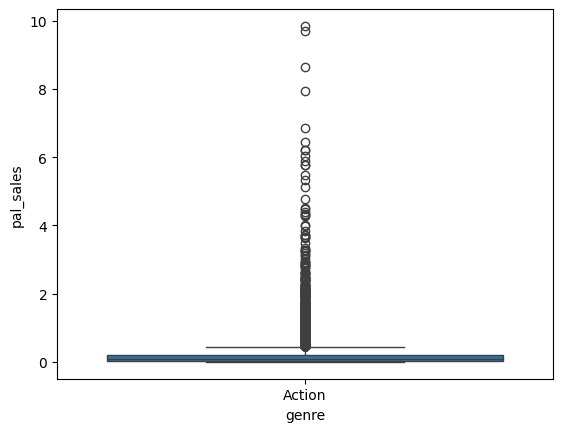

In [16]:
# On veut retire tout les genres qui ne sont pas action
df_action = df[df['genre'] == 'Action']
sns.boxplot(x='genre', y='pal_sales', data=df_action)

## La variance

Observons la variance pour l'une des plateformes

In [17]:
df_Ubisoft = df["pal_sales"][df["publisher"]== "Ubisoft"]

In [18]:
var_ubisoft = np.var(df_Ubisoft)

print(var_ubisoft)

0.2095141760426728


In [19]:
var_ubisoft_ddof = np.var(df_Ubisoft,ddof=1)

print(var_ubisoft_ddof)

0.209823650453371


**Question**: Quel est la différence entre les deux fonctions ? Laquelle faut-il utilser ? **TODO**

**Réponse**: Dans le code source contenant var (*fromnumeric.py*) il est précisé qu'il sagit du **degrée de liberté de delta** (un peu comme pour la loi de Student vu en cours).  
Quand on calcule la variance, on mesure à quel point les données s'écartent de la moyenne.  
La formule est:
$$
    s^2 = \frac{\sum^n_{i=1}(x_i - \bar{x})^2}{n}
$$
Sauf que ici, on ne traite pas **toute** la population des jeux vidéos qui existent, on a qu'un **échantillon**, ce qui introduit un biais quand on estime $\bar{x}$ sur cet échantillon.  
C'est pour cela qu'on utilise la **correction de Bessel** suivante:
$$
    s^2 = \frac{\sum^n_{i=1}(x_i - \bar{x})^2}{\bold{n-1}}
$$

**Question**: La variance permet d'obtenir l'écart type, qui est la racine carrée de la variance. Pourquoi l'écart-type est souvent plus parlant que la variance pour appréhender la dispersion?


<p><b>Réponse</b>: Puisque la variance est la moyenne des carrées, elle est beaucoup moins intuitif à interpréter tandis que l'écart type, lui, utilise les même unitées que celle des données originales, donc plus simple à visualiser.</p>

Donner la variance des pal_sales du publisher Nintendo.
Comparer avec celle d'Ubisoft

In [20]:
df_nintendo = df["pal_sales"][df["publisher"]== "Nintendo"]
var_nintendo  = df_nintendo.var()
var_nintendo_ddof = df_nintendo.var(ddof=1)
print(f"Variance Ubisoft (sans ddof): {var_ubisoft}")
print(f"Variance Nintendo (sans ddof): {var_nintendo}")

print(f"\nVariance Ubisoft (avec ddof): {var_ubisoft_ddof}")
print(f"Variance Nintendo (avec ddof): {var_nintendo_ddof}")

Variance Ubisoft (sans ddof): 0.2095141760426728
Variance Nintendo (sans ddof): 0.010814661269082574

Variance Ubisoft (avec ddof): 0.209823650453371
Variance Nintendo (avec ddof): 0.010814661269082574


<b>Réponse</b>: On remarque que la variance pour nintendo est plus proche de 0, signifiant que les données pour Nintendo s'écartent beaucoup moins de la moyenne que celles d'Ubisoft.

L'analyse de la variance permet d'étudier par exemple le comportement d'une variable qualitative à expliquer en fonction d'une ou de plusieurs variables nominales catégorielles.
Cependant, certain tests sont applicables uniquement si les données suivent une loi normal. Il existe des tests statistiques permettant de savoir si une distribution suit la loi normale.


## Un modèle dit "gaussien"

En théorie des probabilités et en statistique, la loi normale est l'une des lois de probabilités les plus adaptées pour modéliser des phénomènes naturels issus de plusieurs événements aléatoires. Elle est en lien avec de nombreux objets mathématiques dont le mouvement brownien, le bruit blanc gaussien pour ne citez qu'eux. Elle est également appelée loi gaussienne, loi de Gauss ou loi de Laplace-Gauss des noms de Laplace (1749-1827) et Gauss (1777-1855), deux mathématiciens, astronomes et physiciens qui l'ont étudiée.

Plus formellement, c'est une loi de probabilités absolument continue qui dépend de deux paramètres : son espérance, un nombre réel noté $\mu$, et son écart type, un nombre réel strictement positif noté $\sigma $. La densité de probabilité de la loi normale est donnée par :
$$
    f(x) = \frac{1}{\sigma \sqrt{2 \pi }} \exp{ \left( -  \frac{1}{2}  (\frac{x - \mu }{\sigma })^2 \right)}.
$$



La courbe de cette densité est appelée courbe de Gauss ou $\textbf{courbe en cloche}$, entre autres. C'est la représentation la plus connue de cette loi. La loi normale d'espérance nulle et d'écart type unitaire est appelée loi normale centrée réduite ou loi normale standard.

Lorsqu'une variable aléatoire X suit la loi normale, elle est dite gaussienne ou normale et il est habituel d'utiliser la notation avec la variance $\sigma^2$.
Vous comprenez peut-être maintenant pourquoi nous vous avons obligé à connaître la fonction exponentielle. C'est grâce à cette fonction qu'on modélise cette forme de cloche représentative de la gaussienne.
Nous allons essayer de comprendre le pic important suite à notre fonction density().

En statistique, le test de Shapiro–Wilk teste l'hypothèse nulle (aussi appelé hypothèse $H_o$) selon laquelle un échantillon analysé est issu d'une population normalement distribuée. Nous allons regarder si les ventes  sont normalement distribuée pour différents genre

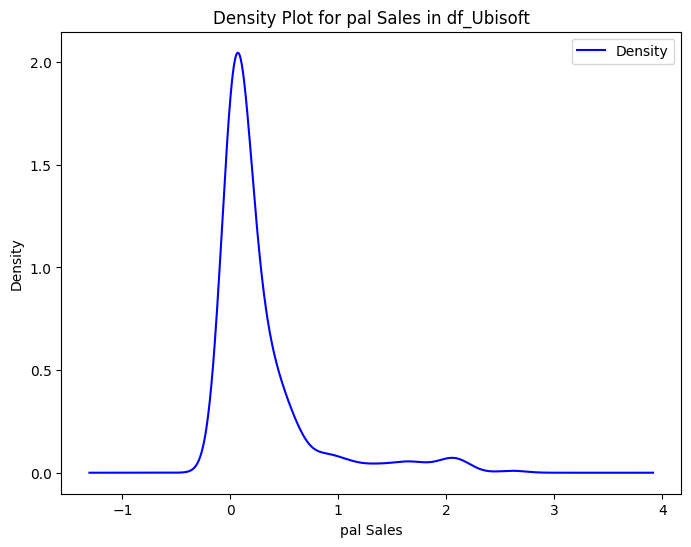

In [21]:
plt.figure(figsize=(8,6))

df_Ubisoft.plot(kind='kde', color='blue', label='Density')

plt.xlabel('pal Sales')
plt.ylabel('Density')
plt.title('Density Plot for pal Sales in df_Ubisoft')

plt.legend()
plt.show()

In [22]:
shapiro_test_ubisoft = stats.shapiro(df_Ubisoft)
print(f"Résultat du test de Shapiro pour Ubisoft: {shapiro_test_ubisoft.statistic}")


Résultat du test de Shapiro pour Ubisoft: nan


<b>Question</b>: Conclure sur les résultats du test

<b>Réponse</b>: On remarque que le résultat obtenu par le test de Shapiro est null (<i>nan</i>), ce qui signifie que les ventes sont normallement distribuée

Effectuer le même test pour la plateforme Nintendo. Comparez les deux résultats

In [23]:
shapiro_test_nintendo = stats.shapiro(df_nintendo)
print(f"Résultat du test de Shapiro pour Nintendo: {shapiro_test_nintendo.statistic}")

Résultat du test de Shapiro pour Nintendo: nan


<b>Réponse</b>: On remarque que pour Nintendo aussi les ventes sont normallement distribuée.

Affichez la courbe de densité des palsales pour le publisher Nintendo

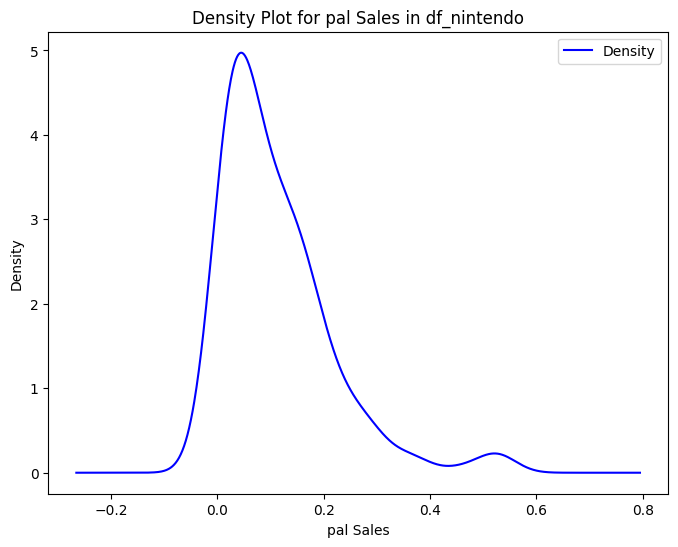

In [24]:
plt.figure(figsize=(8,6))

df_nintendo.plot(kind='kde', color='blue', label='Density')

plt.xlabel('pal Sales')
plt.ylabel('Density')
plt.title('Density Plot for pal Sales in df_nintendo')

plt.legend()
plt.show()

Tester la normalité de la distribution total_sales pour toutes les consoles.

In [25]:
df_total_sales_all_consoles = df["total_sales"]
var_all_consoles  = df_total_sales_all_consoles.var()
var_all_consoles_ddof = df_total_sales_all_consoles.var(ddof=1)

print(f"Variance Total Sales (sans ddof): {var_all_consoles}")
print(f"Variance Total Sales (avec ddof): {var_all_consoles_ddof}")

Variance Total Sales (sans ddof): 0.9652627327231409
Variance Total Sales (avec ddof): 0.9652627327231409


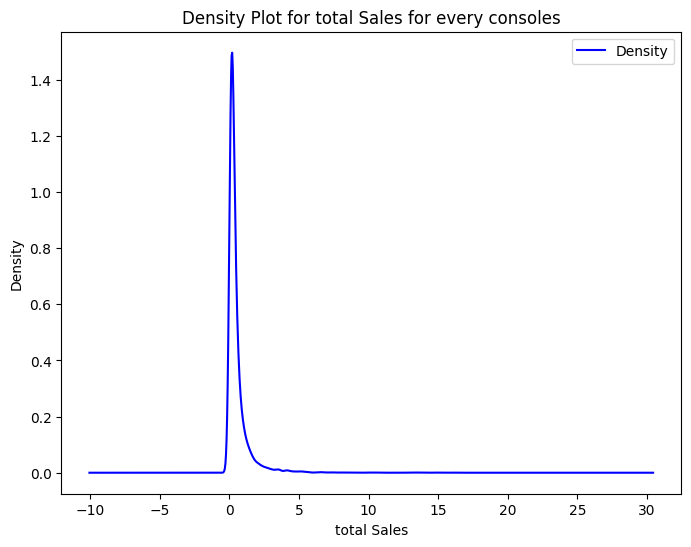

In [26]:
plt.figure(figsize=(8,6))

df_total_sales_all_consoles.plot(kind='kde', color='blue', label='Density')

plt.xlabel('total Sales')
plt.ylabel('Density')
plt.title('Density Plot for total Sales for every consoles')

plt.legend()
plt.show()

In [27]:
shapiro_all_consoles = stats.shapiro(df_total_sales_all_consoles)
print(f"Résultat du test de Shapiro pour Total Sales: {shapiro_all_consoles.statistic}")

Résultat du test de Shapiro pour Total Sales: nan


Lorsqu'on effectue un test de shapiro sur un grand nombre d'observation, le test de shapiro peut-être biaisé.

<b>Question</b>: Expliquez ce que fait le code suivant et conclure sur le résultat du test.

<b>Réponse</b>: Voir commentaires du code.
On utilise ici le <b>test de Kolmogorov-Smirnov</b>, celui-ci permet de comparer si deux échantillons suivent bien la même loi. Donc dans notre cas on compare la distribution de <i>total_sales</i> avec celle de la loi normal. <br>
Si la valeur de retour n'est pas null, cela signifie que la distribution ne suit pas la loi donnée.

In [28]:
mean= df["total_sales"].mean() # On calcule la moyenne de total_sales pour générer une distribution normale avec la même moyenne

sd = np.std(df["total_sales"]) # On calcule l'écart type de total_sales pour générer une distribution normale avec le même écart type

x1 = np.random.normal(loc=mean,scale=sd,size= len(df)) # On génère une distribution normale avec la même moyenne et le même écart type que total_sales
ks_test = stats.kstest(df["total_sales"],x1) # On effectue le test de Kolmogorov-Smirnov pour comparer la distribution de total_sales avec la distribution normale générée
print(ks_test)


KstestResult(statistic=np.float64(nan), pvalue=np.float64(nan), statistic_location=np.float64(nan), statistic_sign=np.float64(nan))


<b>Réponse (suite)</b>: Ici le résultat est <i>null</i> donc <b><i>total_sales</i> suit bien la loi normal</b>. 

## Time to decide
La fonction pointplot() vous permet d'avoir la moyenne et l'intervalle de confiance.
L'intervalle de confiance permet d'évaluer la précision de l'estimation d'un paramètre statistique sur un échantillon.

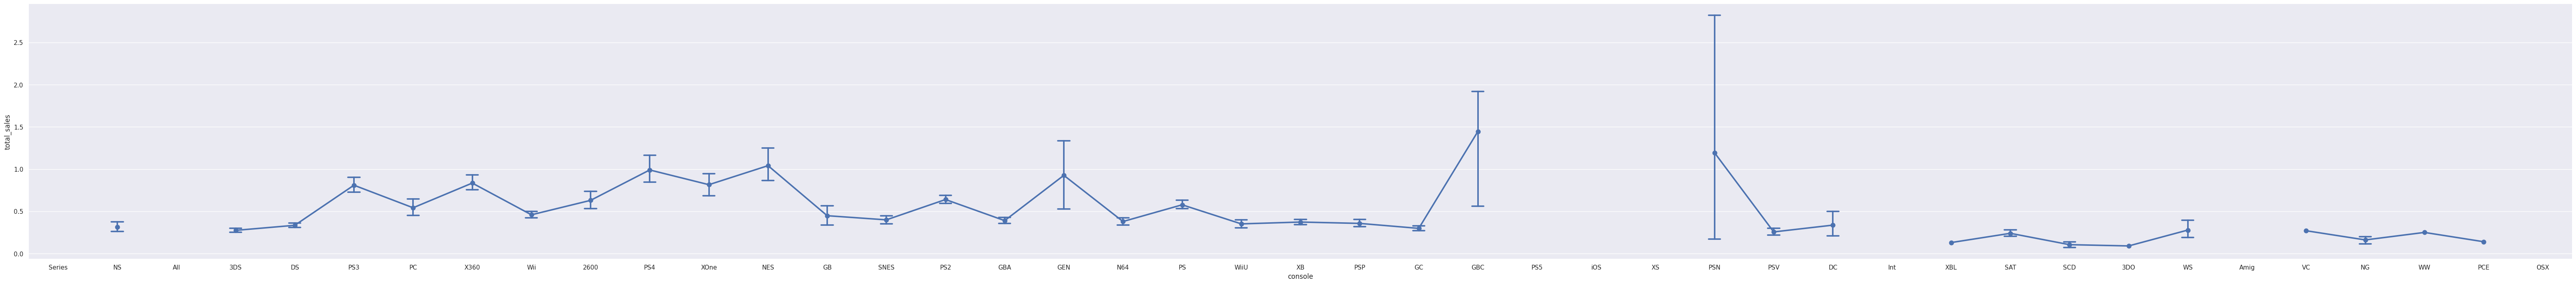

<Figure size 8170x827 with 0 Axes>

In [29]:
sns.set(rc={'figure.figsize':(81.7,8.27)})
ax = sns.pointplot(x=df["console"] ,  y=df["total_sales"], data=df, estimator=np.mean,capsize=.2)
plt.figure()
plt.show()

<b>Question</b>: Expliquez le principe de l'option boxplot.

<b>Réponse</b>: Un bloxplot (ou boite à moustache) permet de représenter l'EIQ (l'étendu interquertile) qui est représenté par: 
$ 
    EIQ = Q_3 - Q_1 
$ 
avec $ Q1 $ la médiane des petites valeurs et $ Q3 $ la médiane des Grandes valeurs. <br>
Si notre valeur est a 1.5 $ EIQ $ des limites de la boite, alors c'est une <b>valeur extrême</b> qu'on représente par des points. 

In [30]:
liste_publishers = df['publisher'].unique()

# Affichez la liste des publishers
print(liste_publishers)

['Ubisoft' 'Nintendo' 'Microsoft' 'Namco' '505 Games' 'Kunos Simulazioni'
 'Capcom' 'Studio Wildcard' 'Koei Tecmo' 'Microsoft Studios'
 'GT Interactive' 'Bohemia Interactive' 'Fox Interactive'
 'Bandai Namco Entertainment' 'Electronic Arts' 'Atari' 'Meridian4'
 'Microsoft Game Studios' 'LucasArts' 'Bethesda Softworks'
 'Rockstar Games' 'Blizzard Entertainment'
 'Warner Bros. Interactive Entertainment' 'Parker Brothers'
 'Telltale Games' 'PopCap Games' 'Sony Interactive Entertainment'
 'Activision' 'KOEI' 'Re-Logic' 'Sega' '2K Games' 'Valve'
 'PUBG Corporation' 'Square Enix' 'EA Sports' 'Mojang' 'THQ' 'Techland'
 'Parker Bros.' 'Astragon' 'CD Projekt Red Studio' 'Curve Digital'
 'Konami' 'Namco Bandai Games' 'PF.Magic' 'Square' 'Melbourne House'
 'Bandai' 'Psygnosis' 'Maxis' 'Agetec' 'Rebellion Developments'
 'Chucklefish' 'ConcernedApe' 'Atlus' 'Sony Computer Entertainment'
 'Hasbro Interactive' 'Eidos Interactive' 'Deep Silver'
 'Bandai Namco Games' 'VU Games' 'Humongous Entertainment

À partir de la liste des publisher ci-dessus, créer un dataset avec uniquement des publisher de cette listes

In [41]:
liste_publishers = ['Ubisoft', 'Nintendo' ,'Microsoft','Epic Games'  ,  'Blizzard Entertainment',  'GT Interactive' , 'Electronic Arts' 'Atari' , 'Microsoft Game Studios' , 'LucasArts' , 'Rockstar Games']

# isin nous permet de filter les lignes du dataframe, si publisher fait partie de la liste des publishers alors on garde la ligne
subset_df = df[df['publisher'].isin(liste_publishers)]

print(subset_df['publisher'].unique())

['Ubisoft' 'Nintendo' 'Microsoft' 'GT Interactive'
 'Microsoft Game Studios' 'LucasArts' 'Rockstar Games'
 'Blizzard Entertainment' 'Epic Games']


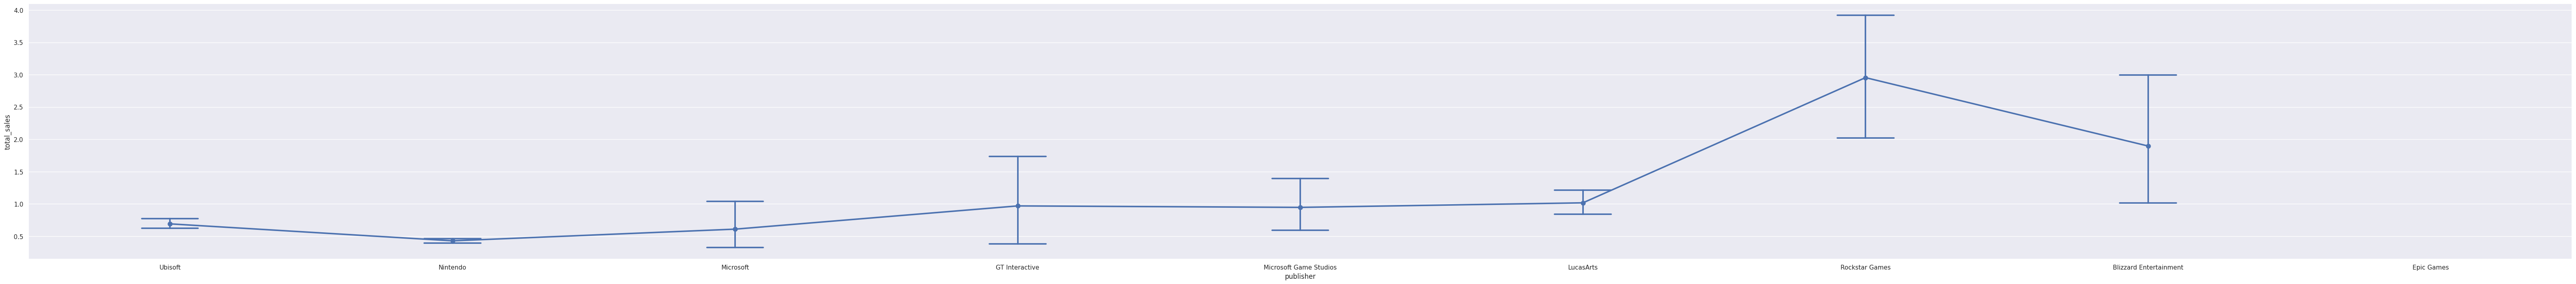

<Figure size 8170x827 with 0 Axes>

In [32]:
ax = sns.pointplot(x=subset_df["publisher"] ,  y=subset_df["total_sales"], data=subset_df, estimator=np.mean,capsize=.2)
plt.figure()
plt.show()

Séléctionner les jeux créee depuis plus de 2014. Comparer avec la courbe précédente la différence

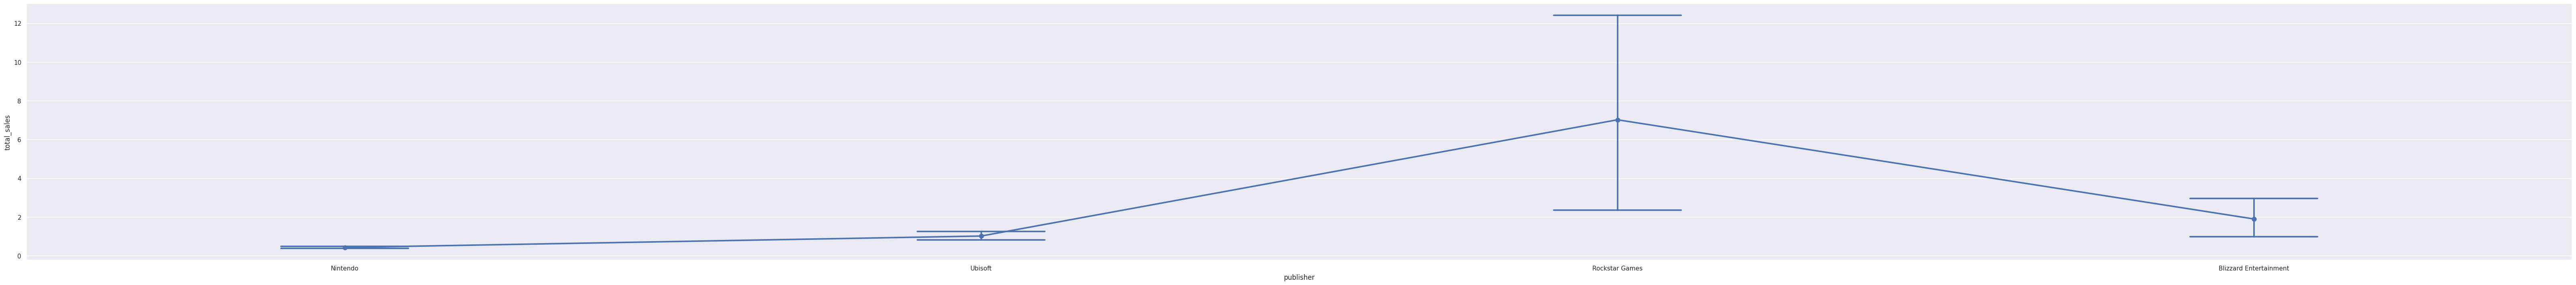

<Figure size 8170x827 with 0 Axes>

In [33]:
# On sélectionne uniquement les jeux qui sont sortis après 2013 dans subset_df
subset_df_after_2013 = subset_df[subset_df['Year'] > 2013]

ax = sns.pointplot(x=subset_df_after_2013["publisher"] ,  y=subset_df_after_2013["total_sales"], data=subset_df_after_2013, estimator=np.mean,capsize=.2)
plt.figure()
plt.show()

Appliquez un centrage réduction sur vos données depuis 2014 et comparer les résultats avec la courbe précédente.

<i>Une variable centrée réduite est la variable transformée d'une variable aléatoire par une application affine, de tel sorte que sa moyenne soit nulle et son écart type égale à un.</i> <br>

On a $\mu$ l'espérance et $\sigma$ l'écart type d'une variable aléatoire. Centrer-réduire l'une de ses valeurs X revient à calculer:
$$
    x = \frac{X - \mu}{\sigma}
$$
Cela facilite la comparaison entre différentes variable ou jeux de données.

<i>Source: <a href="https://fr.wikipedia.org/wiki/Variable_centr%C3%A9e_r%C3%A9duite">Wikipedia: variable dentrée réduite</a></i>

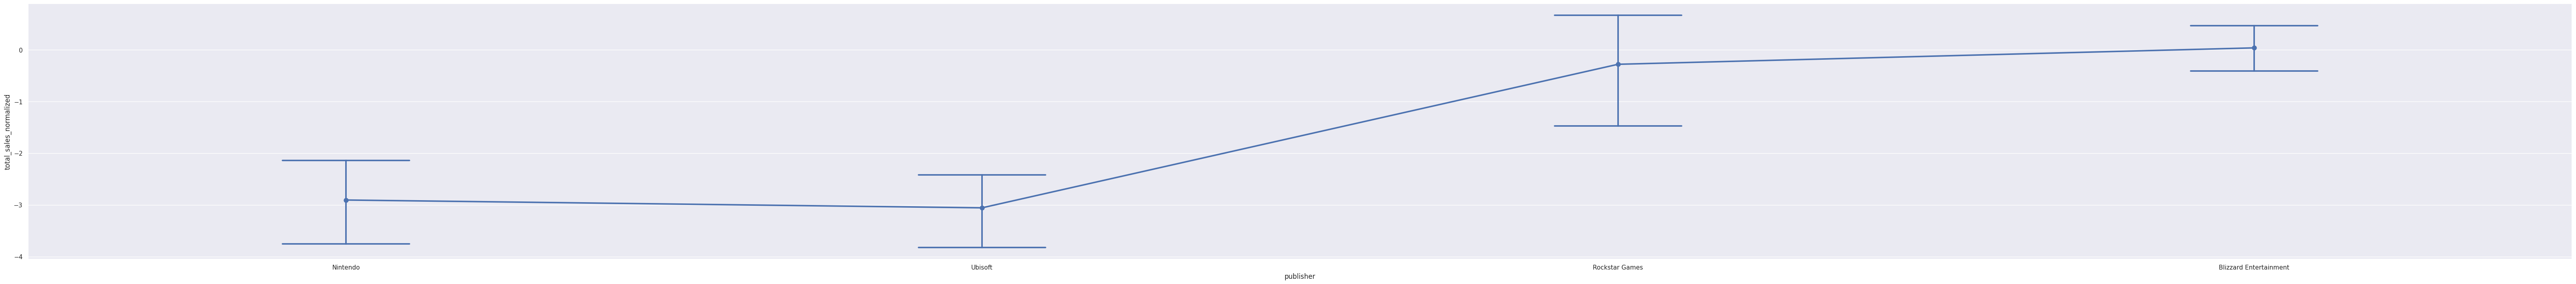

<Figure size 8170x827 with 0 Axes>

In [34]:
# On fait une copie de subset_df_after_2013 pour éviter les SettingWithCopyWarning
subset_df_after_2013 = subset_df_after_2013.copy()

# On applique un centrage réduction sur subset_df_after_2013
subset_df_after_2013.loc[:,'total_sales_normalized'] = (subset_df_after_2013['total_sales'] - subset_df_after_2013['total_sales'].mean()) / subset_df_after_2013['total_sales']

ax = sns.pointplot(x=subset_df_after_2013["publisher"] ,  y=subset_df_after_2013["total_sales_normalized"], data=subset_df_after_2013, estimator=np.mean,capsize=.2)
plt.figure()
plt.show()

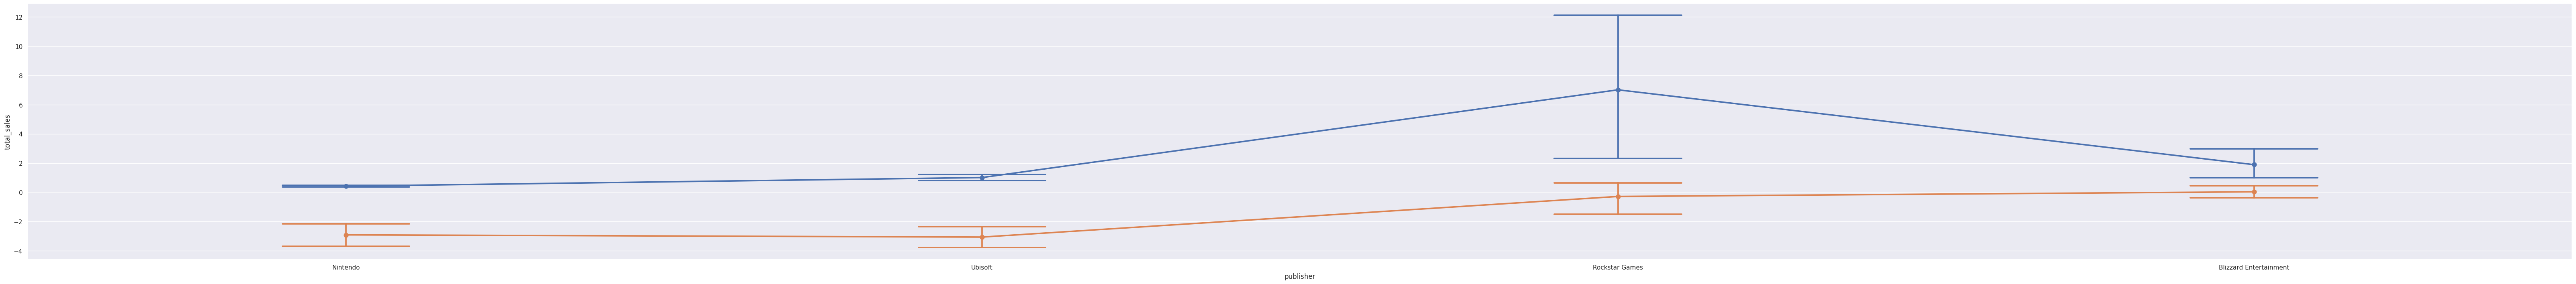

<Figure size 8170x827 with 0 Axes>

In [35]:
# On compare subset_df_after_2013 avant et après centrage réduit
ax1 = sns.pointplot(x=subset_df_after_2013["publisher"] ,  y=subset_df_after_2013["total_sales"], data=subset_df_after_2013, estimator=np.mean,capsize=.2)
ax2 = sns.pointplot(x=subset_df_after_2013["publisher"] ,  y=subset_df_after_2013["total_sales_normalized"], data=subset_df_after_2013, estimator=np.mean,capsize=.2)
plt.figure()
plt.show()

Séléctionner un dataset ne contenant que des jeux du publisher Rockstar Games

In [61]:
rockstar_games_df = df[df['publisher'] == 'Rockstar Games']
print(f"Nombre de jeux de Rockstar Games : {rockstar_games_df['title'].nunique()}")

Nombre de jeux de Rockstar Games : 48


Construire un interval de confiance autour des ventes de tous les continents pour les jeux de Rockstar games.

L'intervalle de confiance pour une moyenne peut être définit de la sorte:
$$
    I = \bar{x} \pm t_{\frac{\alpha}{2}} . s(\bar{x})
$$
Avec pour $s(\bar{x})$: 
$$
    s(\bar{x}) = \frac{s}{\sqrt{n}}
$$
Avec:
- $\bar{x}$ la moyenne des ventes totales
- $t_{\frac{\alpha}{2}}$ le niveau de confiance (suivant la loi normal car $n > 30$)
- $s$ l'écart type pour les jeux vendus
- $n$ le nombre de ventes


In [67]:
import scipy.stats as st

echantillon = rockstar_games_df['total_sales']
n = len(echantillon)
x_barre = echantillon.mean()
s = echantillon.std(ddof=1)
s_x_barre = s/np.sqrt(n)

intervalle = st.norm.interval(0.95, loc=x_barre, scale=s_x_barre)

print(f"Ventes totales moyenne de Rockstar Games : {x_barre:.2f}")
print(f"Intervalle de confiance à 95% : [{intervalle[0]:.2f}, {intervalle[1]:.2f}]")

Ventes totales moyenne de Rockstar Games : 2.96
Intervalle de confiance à 95% : [2.09, 3.82]


Construire un interval de confiance autour des ventes totales pour chaque plateforme possible pour les jeux de Rockstar games.

In [86]:
def intervalle_confiance_normal(data, confidence=0.95):
    n = len(data)
    x_barre = data.mean()
    s = data.std(ddof=1)
    s_x_barre = s/np.sqrt(n)
    
    intervalle = st.norm.interval(confidence, loc=x_barre, scale=s_x_barre)
    
    return x_barre, intervalle

def intervalle_confiance_student(data, confidence=0.95):
    n = len(data)
    x_barre = data.mean()
    s = data.std(ddof=1)
    s_x_barre = s/np.sqrt(n)
    
    intervalle = st.t.interval(confidence, df=n-1, loc=x_barre, scale=s_x_barre)
    
    return x_barre, intervalle

In [76]:
# On regarde le nombre de plateformes différentes
print(f"Nombre de plateformes différentes pour les jeux Rockstar Games : {rockstar_games_df['console'].nunique()}")

Nombre de plateformes différentes pour les jeux Rockstar Games : 18


In [94]:
# On définit un tableau à deux dimenssions avec (plateform, total_sales)
# on vautiliser groupby pour pouvoir groupper les données par plateforme
# et ensuite faire la somme des totale_sales pour ses plateformes là
sales_per_platform = rockstar_games_df.groupby('console')['total_sales'].sum().reset_index()
sales_per_platform.columns = ['console', 'total_sales']
print(sales_per_platform)

# On retire les plateformes qui ont moins de 2 échantillons pour pouvoir calculer un intervalle de confiance
platforms_to_analyze = sales_per_platform[sales_per_platform['total_sales'] >= 2]['console']
print(f"Plateformes à analyser : {platforms_to_analyze.tolist()}")

   console  total_sales
0      All         0.00
1       DS         1.33
2      GBA         0.24
3       GC         0.08
4      N64         0.42
5       NS         0.45
6       PC         1.93
7       PS         3.92
8      PS2        57.65
9      PS3        48.30
10     PS4        33.93
11     PSP        19.23
12  Series         0.00
13     Wii         2.30
14    X360        45.76
15      XB         9.02
16     XBL         0.13
17    XOne        14.74
Plateformes à analyser : ['PS', 'PS2', 'PS3', 'PS4', 'PSP', 'Wii', 'X360', 'XB', 'XOne']


In [105]:
# Il nous suffit juste maintenant d'appliquer intervalle_confiance sur toutes les platerformes
for platform in platforms_to_analyze:
    # Récupérer les ventes totales pour la plateforme actuelle depuis sales_per_platform
    total_sales_row = sales_per_platform[sales_per_platform['console'] == platform]
    if total_sales_row.empty:
        continue
    total_sales = total_sales_row['total_sales'].values[0]
    
    # On sélectionne les ventes totales pour la plateforme actuelle
    platform_sales = rockstar_games_df[rockstar_games_df['console'] == platform]['total_sales']
    
    n = len(platform_sales)
    if n < 2:
        # print(f"Plateforme: {platform} - Pas assez de données (n={n}) pour calculer un intervalle de confiance")
        # print()
        continue
    
    # On regarde le nombre d'échantillons pour la plateforme actuelle, si > 30 alors on utilise la loi Normal, si non Student  
    if n > 30:
        mean, intervalle = intervalle_confiance_normal(platform_sales)
    else:
        mean, intervalle = intervalle_confiance_student(platform_sales)
        
    print(f"Plateforme: {platform}")
    print(f"Ventes totales: {total_sales:.2f}")
    print(f"Intervalle de confiance à 95% pour les ventes totales : [{intervalle[0]:.2f}, {intervalle[1]:.2f}]")
    print()

Plateforme: PC
Ventes totales: 14.28
Intervalle de confiance à 95% pour les ventes totales : [0.14, 1.15]

Plateforme: PS
Ventes totales: 3.96
Intervalle de confiance à 95% pour les ventes totales : [-3.25, 5.87]

Plateforme: PS2
Ventes totales: 29.36
Intervalle de confiance à 95% pour les ventes totales : [0.99, 4.50]

Plateforme: PS3
Ventes totales: 90.53
Intervalle de confiance à 95% pour les ventes totales : [0.55, 11.53]

Plateforme: PS4
Ventes totales: 74.29
Intervalle de confiance à 95% pour les ventes totales : [-12.70, 35.32]

Plateforme: PSP
Ventes totales: 7.26
Intervalle de confiance à 95% pour les ventes totales : [0.06, 4.75]

Plateforme: Wii
Ventes totales: 62.90
Intervalle de confiance à 95% pour les ventes totales : [-0.30, 1.83]

Plateforme: X360
Ventes totales: 100.02
Intervalle de confiance à 95% pour les ventes totales : [0.94, 8.22]

Plateforme: XB
Ventes totales: 19.73
Intervalle de confiance à 95% pour les ventes totales : [0.27, 1.24]

Plateforme: XOne
Ventes t

On remarque que par exemple pour la PS4 l'intervalle est extrèmement grand (allant même dans les négatifs), cela signifie que son écart type est important. 
Plus concrètement, cela signifie que les ventes varient beaucoup (certains jeux sont des succès, d'autres non).

Effectuez les 2 dernières analyses pour les jeux du publisher Ubisoft.

In [102]:
ubisoft_games_df = df[df['publisher'] == 'Ubisoft']

sales_per_platform = ubisoft_games_df.groupby('console')['total_sales'].sum().reset_index()
sales_per_platform.columns = ['console', 'total_sales']
print(sales_per_platform)

# On retire les plateformes qui ont moins de 2 échantillons pour pouvoir calculer un intervalle de confiance
platforms_to_analyze = sales_per_platform[sales_per_platform['total_sales'] >= 2]['console']
print(f"Plateformes à analyser : {platforms_to_analyze.tolist()}")

   console  total_sales
0      3DS         4.29
1      All         0.00
2       DC         0.20
3       DS        54.88
4      GBA         4.89
5       GC         2.76
6      N64         1.47
7       NS         3.68
8       PC        14.28
9       PS         3.96
10     PS2        29.36
11     PS3        90.53
12     PS4        74.29
13     PSP         7.26
14     PSV         3.03
15  Series         0.00
16     Wii        62.90
17    WiiU         6.32
18    X360       100.02
19      XB        19.73
20    XOne        36.63
Plateformes à analyser : ['3DS', 'DS', 'GBA', 'GC', 'NS', 'PC', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']


In [104]:
# Il nous suffit juste maintenant d'appliquer intervalle_confiance sur toutes les platerformes
for platform in platforms_to_analyze:
    # Récupérer les ventes totales pour la plateforme actuelle depuis sales_per_platform
    total_sales_row = sales_per_platform[sales_per_platform['console'] == platform]
    if total_sales_row.empty:
        continue
    total_sales = total_sales_row['total_sales'].values[0]
    
    # On sélectionne les ventes totales pour la plateforme actuelle
    platform_sales = ubisoft_games_df[ubisoft_games_df['console'] == platform]['total_sales']
    
    n = len(platform_sales)
    if n < 2:
        # print(f"Plateforme: {platform} - Pas assez de données (n={n}) pour calculer un intervalle de confiance")
        # print()
        continue
    
    # On regarde le nombre d'échantillons pour la plateforme actuelle, si > 30 alors on utilise la loi Normal, si non Student  
    if n > 30:
        mean, intervalle = intervalle_confiance_normal(platform_sales)
    else:
        mean, intervalle = intervalle_confiance_student(platform_sales)
        
    print(f"Plateforme: {platform}")
    print(f"Ventes totales: {total_sales:.2f}")
    print(f"Intervalle de confiance à 95% pour les ventes totales : [{intervalle[0]:.2f}, {intervalle[1]:.2f}]")
    print()

Plateforme: 3DS
Ventes totales: 4.29
Intervalle de confiance à 95% pour les ventes totales : [0.15, 0.30]

Plateforme: DS
Ventes totales: 54.88
Intervalle de confiance à 95% pour les ventes totales : [0.32, 0.47]

Plateforme: GBA
Ventes totales: 4.89
Intervalle de confiance à 95% pour les ventes totales : [0.15, 0.32]

Plateforme: GC
Ventes totales: 2.76
Intervalle de confiance à 95% pour les ventes totales : [0.11, 0.18]

Plateforme: NS
Ventes totales: 3.68
Intervalle de confiance à 95% pour les ventes totales : [0.26, 0.66]

Plateforme: PC
Ventes totales: 14.28
Intervalle de confiance à 95% pour les ventes totales : [0.31, 0.48]

Plateforme: PS
Ventes totales: 3.96
Intervalle de confiance à 95% pour les ventes totales : [-0.44, 1.57]

Plateforme: PS2
Ventes totales: 29.36
Intervalle de confiance à 95% pour les ventes totales : [0.41, 0.72]

Plateforme: PS3
Ventes totales: 90.53
Intervalle de confiance à 95% pour les ventes totales : [0.85, 1.60]

Plateforme: PS4
Ventes totales: 74.29

**Question**: Conclure sur leurs performances respectives

**Réponse**: Si on devait faire une comparaison directe entre Ubisoft et Rockstar Games on pourrait dire que Ubisoft est beaucoup plus stable en terme de vente sur la plupart des pateformes qui sont en commun avec RG.
Cela est dû aux nombre de jeux produit qui sont bien plus élevé pour Ubisoft.  
Ubisoft produit plus de jeux qui ont plus ou moins le même succée, d'ou l'écart type petit, tandis que RC lui produit beaucoup moins de jeux et leurs succées peuvent énormément varier, ce qui impacte beaucoup l'écart type.